# **Project Name**    - Brain Tumor MRI Image Classification


##### **Project Type**    - Classification (Deep Learning - Image Classification)
##### **Contribution**    - Individual
##### **Name -** Punati Venkata Sai Ravish


# **Project Summary**


This project focuses on developing a deep learning-based solution for classifying brain MRI images into four categories: Glioma Tumor, Meningioma Tumor, Pituitary Tumor, and No Tumor. The goal is to assist radiologists and medical professionals in faster and more accurate diagnosis of brain tumors using Artificial Intelligence.

The dataset used contains 2443 labeled MRI images, split into training (1695), validation (502), and test (246) sets. All images are of consistent resolution (640×640) and are in RGB format. There is a mild class imbalance, with Glioma being the most frequent class and No Tumor being the least frequent.

The project workflow includes thorough Exploratory Data Analysis (EDA), data preprocessing, data augmentation, building a Custom Convolutional Neural Network (CNN) from scratch, and applying Transfer Learning using popular pretrained models such as MobileNetV2, EfficientNetB0, and ResNet50. Models are evaluated using accuracy, precision, recall, F1-score, and confusion matrix. The best performing model is selected for deployment.

Finally, a user-friendly Streamlit web application is built so that users can upload an MRI image and receive real-time predictions along with confidence scores. This end-to-end solution demonstrates the practical application of Deep Learning in medical imaging and has strong potential for real-world use in hospitals and telemedicine platforms.

# **GitHub Link**


### 

# **Problem Statement**


Brain tumors are among the most critical neurological conditions, and timely diagnosis significantly impacts patient outcomes. Traditional diagnosis relies on radiologists manually examining MRI scans, which is time-consuming and subject to inter-observer variability.

This project aims to build an automated deep learning system that can classify brain MRI images into four categories:
1. Glioma Tumor
2. Meningioma Tumor
3. Pituitary Tumor
4. No Tumor

The solution involves building a custom CNN architecture from scratch, leveraging transfer learning with state-of-the-art pretrained models, comparing model performance rigorously, and deploying the best model via a user-friendly Streamlit application for real-time inference.

The goal is to assist medical professionals with faster, consistent, and accurate preliminary classification of brain tumors from MRI scans.


# **General Guidelines** : -


1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.


# ***Let's Begin !***


## ***1. Know Your Data***


### Import Libraries


In [1]:
# Import Libraries
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Dense, Flatten,
                                     Dropout, BatchNormalization, GlobalAveragePooling2D)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('TensorFlow version:', tf.__version__)
print('GPU Available:', tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


### Dataset Loading


In [2]:
# ============================================================
# DATASET LOADING
# ============================================================

DATA_DIR = '/kaggle/input/datasets/sairavishpv/mri-brain-tumor-dataset-v1-version-1-multiclass/Labeled MRI Brain Tumor Dataset.v1-version-1.multiclass'

print('DATA_DIR:', DATA_DIR)
print('Exists:', os.path.exists(DATA_DIR))
print('Contents:', os.listdir(DATA_DIR))

train_df = pd.read_csv(os.path.join(DATA_DIR, 'train', '_classes.csv'))
valid_df = pd.read_csv(os.path.join(DATA_DIR, 'valid', '_classes.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'test',  '_classes.csv'))

# Clean column names
train_df.columns = train_df.columns.str.strip()
valid_df.columns = valid_df.columns.str.strip()
test_df.columns  = test_df.columns.str.strip()

print('\nTrain shape:', train_df.shape)
print('Valid shape:', valid_df.shape)
print('Test shape :', test_df.shape)

DATA_DIR: /kaggle/input/datasets/sairavishpv/mri-brain-tumor-dataset-v1-version-1-multiclass/Labeled MRI Brain Tumor Dataset.v1-version-1.multiclass
Exists: True
Contents: ['README.dataset.txt', 'README.roboflow.txt', 'valid', 'test', 'train']

Train shape: (1695, 5)
Valid shape: (502, 5)
Test shape : (246, 5)


### Dataset First View


In [3]:
print('=== TRAIN ===')
display(train_df.head())
print('\n=== VALID ===')
display(valid_df.head())
print('\n=== TEST ===')
display(test_df.head())


=== TRAIN ===


,filename,Glioma,Meningioma,No Tumor,Pituitary
0,Tr-pi_0164_jpg.rf.000776527ec0acdc89e31e15a352...,0,0,0,1
1,Tr-no_0426_jpg.rf.0026b06f369c5d51aca4c4c9beba...,0,0,1,0
2,Tr-gl_0496_jpg.rf.010620fbbbaa509aa81d7ce5bdf7...,1,0,0,0
3,Tr-gl_0554_jpg.rf.010a72c1c25cc9ce83c77fbb23db...,1,0,0,0
4,Tr-me_0185_jpg.rf.0094b0b539582e2f95ae7b6ada4d...,0,1,0,0



=== VALID ===


,filename,Glioma,Meningioma,No Tumor,Pituitary
0,Tr-me_0034_jpg.rf.623f1cc8f30e4ef5baa02759f4f9...,0,1,0,0
1,Tr-pi_0310_jpg.rf.6a7af3a7e47e29504b29815e7e25...,0,0,0,1
2,Tr-gl_0239_jpg.rf.6e5cff37515b73707663e8ff1537...,1,0,0,0
3,Tr-no_0052_jpg.rf.6a63634edac060a9076b23ce6f6f...,0,0,1,0
4,Tr-gl_0550_jpg.rf.667b7e2e928c9e4ac209da273de2...,1,0,0,0



=== TEST ===


,filename,Glioma,Meningioma,No Tumor,Pituitary
0,Tr-me_0044_jpg.rf.0223369274dd825d3ff27ace105f...,0,1,0,0
1,Tr-gl_0094_jpg.rf.1c0f0e197cfcf7728469ebc07bc6...,1,0,0,0
2,Tr-pi_0130_jpg.rf.15adee5c88949e10f62a9c54294a...,0,0,0,1
3,Tr-gl_0386_jpg.rf.1323d579421a7a8b821ce882e2a0...,1,0,0,0
4,Tr-no_0477_jpg.rf.19bfdb70a263ae878bd1a2b39719...,0,0,1,0


### Dataset Rows & Columns count


In [4]:
print('Train  - Rows: {}, Columns: {}'.format(*train_df.shape))
print('Valid  - Rows: {}, Columns: {}'.format(*valid_df.shape))
print('Test   - Rows: {}, Columns: {}'.format(*test_df.shape))
print('Total Images:', len(train_df) + len(valid_df) + len(test_df))


Train  - Rows: 1695, Columns: 5
Valid  - Rows: 502, Columns: 5
Test   - Rows: 246, Columns: 5
Total Images: 2443


### Dataset Information


In [5]:
print('=== TRAIN INFO ===')
train_df.info()
print('\n=== VALID INFO ===')
valid_df.info()
print('\n=== TEST INFO ===')
test_df.info()


=== TRAIN INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1695 entries, 0 to 1694
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   filename    1695 non-null   object
 1   Glioma      1695 non-null   int64 
 2   Meningioma  1695 non-null   int64 
 3   No Tumor    1695 non-null   int64 
 4   Pituitary   1695 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 66.3+ KB

=== VALID INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   filename    502 non-null    object
 1   Glioma      502 non-null    int64 
 2   Meningioma  502 non-null    int64 
 3   No Tumor    502 non-null    int64 
 4   Pituitary   502 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 19.7+ KB

=== TEST INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 24

#### Duplicate Values


In [6]:
print('Train duplicates:', train_df.duplicated().sum())
print('Valid duplicates:', valid_df.duplicated().sum())
print('Test duplicates :', test_df.duplicated().sum())
print('Train filename duplicates:', train_df['filename'].duplicated().sum())


Train duplicates: 0
Valid duplicates: 0
Test duplicates : 0
Train filename duplicates: 0


#### Missing Values/Null Values


Train missing:
 filename      0
Glioma        0
Meningioma    0
No Tumor      0
Pituitary     0
dtype: int64

Valid missing:
 filename      0
Glioma        0
Meningioma    0
No Tumor      0
Pituitary     0
dtype: int64

Test missing:
 filename      0
Glioma        0
Meningioma    0
No Tumor      0
Pituitary     0
dtype: int64


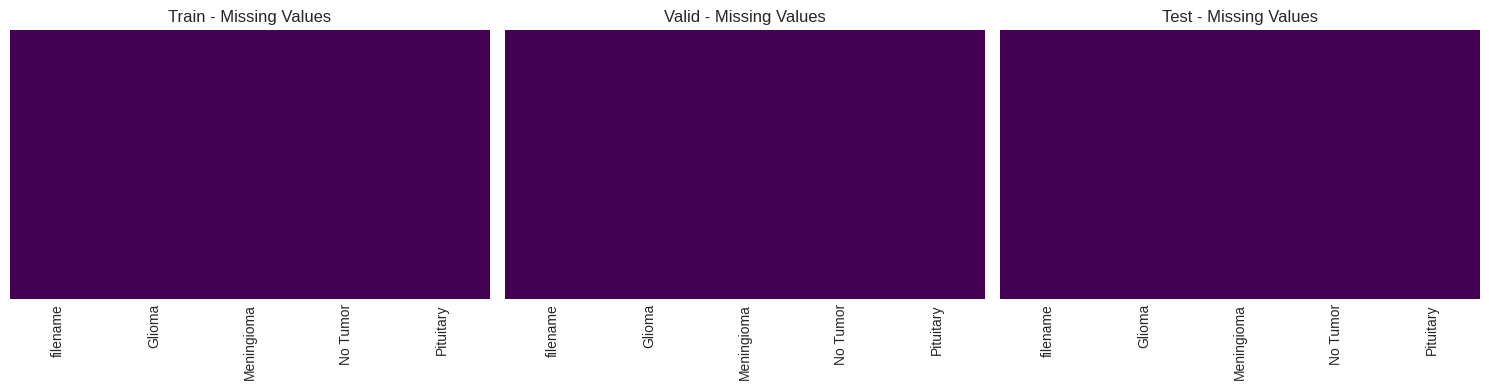

In [7]:
print('Train missing:\n', train_df.isnull().sum())
print('\nValid missing:\n', valid_df.isnull().sum())
print('\nTest missing:\n', test_df.isnull().sum())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, df, title in zip(axes, [train_df, valid_df, test_df], ['Train', 'Valid', 'Test']):
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=ax)
    ax.set_title(f'{title} - Missing Values')
plt.tight_layout()
plt.show()


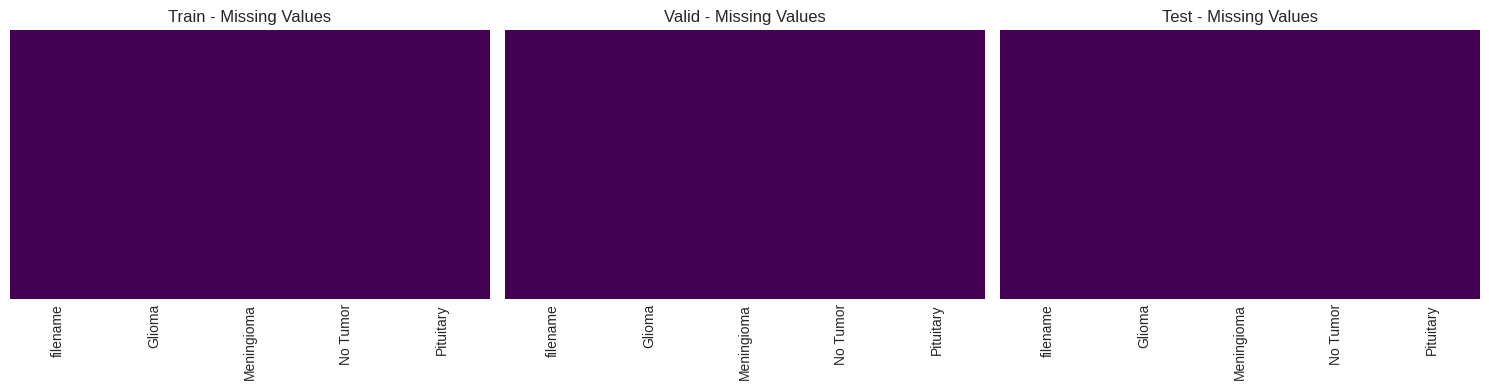

In [8]:
# Visualizing the missing values
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, df, title in zip(axes, [train_df, valid_df, test_df], ['Train', 'Valid', 'Test']):
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=ax)
    ax.set_title(f'{title} - Missing Values')
plt.tight_layout()
plt.show()


### What did you know about your dataset?


**Answer:**

- The dataset contains **2,443 brain MRI images** labeled into 4 classes: Glioma, Meningioma, No Tumor, and Pituitary.
- Split: Train (1,695), Validation (502), Test (246).
- Labels are provided in one-hot encoded CSV format (`_classes.csv`) alongside image filenames.
- No missing values or duplicate records found.
- All images are RGB and consistently sized at 640x640 pixels.
- Mild class imbalance exists (Glioma ~33%, No Tumor ~19.8%).
- This is an image classification dataset suitable for CNN and transfer learning approaches.


## ***2. Understanding Your Variables***


In [9]:
print('Columns:', list(train_df.columns))


Columns: ['filename', 'Glioma', 'Meningioma', 'No Tumor', 'Pituitary']


In [10]:
# Dataset Describe
display(train_df.describe())


,Glioma,Meningioma,No Tumor,Pituitary
count,1695.000000,1695.000000,1695.000000,1695.000000
mean,0.332743,0.211209,0.197640,0.258407
std,0.471335,0.408287,0.398337,0.437888
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000


### Variables Description


**Answer:**

| Variable   | Description                                   |
|------------|-----------------------------------------------|
| filename   | Name of the MRI image file                    |
| Glioma     | One-hot label (1 if Glioma tumor, else 0)     |
| Meningioma | One-hot label (1 if Meningioma tumor, else 0) |
| No Tumor   | One-hot label (1 if no tumor present, else 0) |
| Pituitary  | One-hot label (1 if Pituitary tumor, else 0)  |

Each image belongs to exactly one class (multi-class, single-label classification).


### Check Unique Values for each variable.


In [11]:
print('Unique filenames (train):', train_df['filename'].nunique())
for col in ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']:
    print(f'{col}: {train_df[col].unique()}')


Unique filenames (train): 1695
Glioma: [0 1]
Meningioma: [0 1]
No Tumor: [0 1]
Pituitary: [1 0]


## 3. ***Data Wrangling***


In [12]:
CLASS_NAMES = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

def get_label(row):
    for cls in CLASS_NAMES:
        if row[cls] == 1:
            return cls
    return 'Unknown'

train_df['label'] = train_df.apply(get_label, axis=1)
valid_df['label'] = valid_df.apply(get_label, axis=1)
test_df['label']  = test_df.apply(get_label, axis=1)

train_df['path'] = train_df['filename'].apply(lambda x: os.path.join(DATA_DIR, 'train', x))
valid_df['path'] = valid_df['filename'].apply(lambda x: os.path.join(DATA_DIR, 'valid', x))
test_df['path']  = test_df['filename'].apply(lambda x: os.path.join(DATA_DIR, 'test', x))

print('Train label distribution:')
print(train_df['label'].value_counts())
print('\nSample:')
print(train_df[['filename', 'label']].head(3))


Train label distribution:
label
Glioma        564
Pituitary     438
Meningioma    358
No Tumor      335
Name: count, dtype: int64

Sample:
                                            filename      label
0  Tr-pi_0164_jpg.rf.000776527ec0acdc89e31e15a352...  Pituitary
1  Tr-no_0426_jpg.rf.0026b06f369c5d51aca4c4c9beba...   No Tumor
2  Tr-gl_0496_jpg.rf.010620fbbbaa509aa81d7ce5bdf7...     Glioma


### What all manipulations have you done and insights you found?


**Answer:**

**Manipulations:**
1. Cleaned column names (stripped spaces).
2. Converted one-hot labels into a single `label` column.
3. Created full image path column for each split.
4. Verified no missing or duplicate values.

**Insights:**
- Dataset is clean and ready for deep learning.
- Mild class imbalance present → class weights recommended.
- Consistent 640x640 resolution.
- Four mutually exclusive classes → multi-class classification.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***


#### Chart - 1


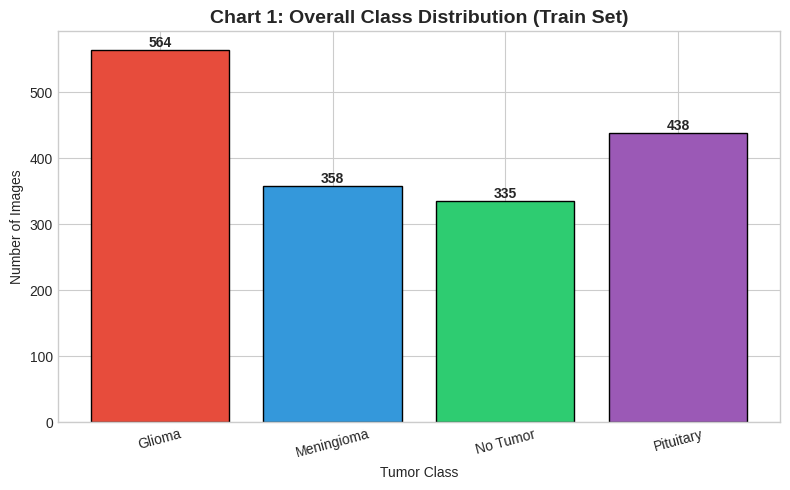

In [13]:
# Chart - 1 visualization code
fig, ax = plt.subplots(figsize=(8, 5))
counts = train_df['label'].value_counts().reindex(CLASS_NAMES)
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='black')
ax.set_title('Chart 1: Overall Class Distribution (Train Set)', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Images')
ax.set_xlabel('Tumor Class')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val), ha='center', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?


A bar chart is the most effective way to compare the frequency of categorical classes at a glance.


##### 2. What is/are the insight(s) found from the chart?


Glioma has the highest number of samples (564), followed by Pituitary (438), Meningioma (358), and No Tumor (335). There is a mild imbalance.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Yes. Knowing the imbalance helps us apply class weights or augmentation strategies so the model does not become biased toward Glioma, which is critical for reliable medical diagnosis.


#### Chart - 2


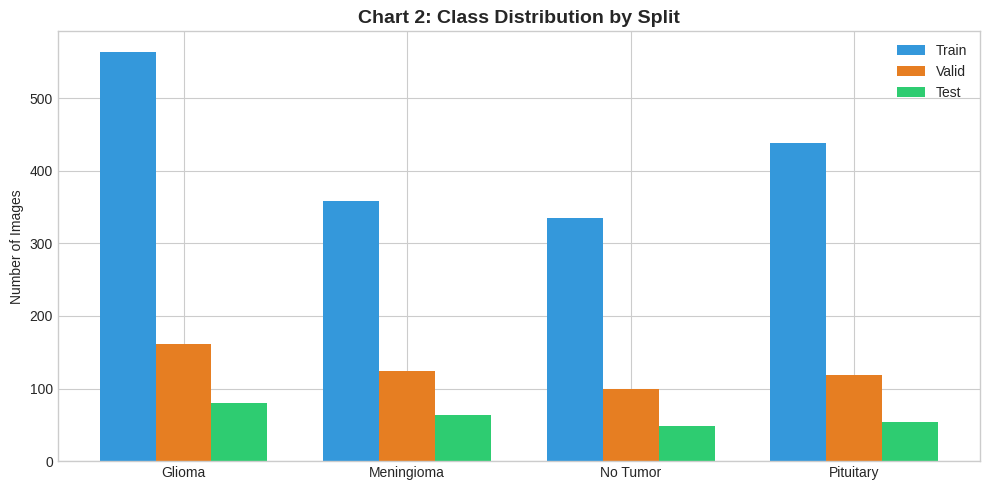

In [14]:
# Chart - 2 visualization code
x = np.arange(len(CLASS_NAMES))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, train_df['label'].value_counts().reindex(CLASS_NAMES), width, label='Train', color='#3498db')
ax.bar(x,         valid_df['label'].value_counts().reindex(CLASS_NAMES), width, label='Valid', color='#e67e22')
ax.bar(x + width, test_df['label'].value_counts().reindex(CLASS_NAMES),  width, label='Test',  color='#2ecc71')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.set_title('Chart 2: Class Distribution by Split', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Images')
ax.legend()
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?


Grouped bar chart clearly shows how each class is distributed across train, validation, and test sets.


##### 2. What is/are the insight(s) found from the chart?


All splits maintain roughly similar class proportions, indicating a proper split. Test set is smaller but representative.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Yes. Consistent distribution across splits ensures evaluation metrics on the test set are reliable and generalizable.


#### Chart - 3


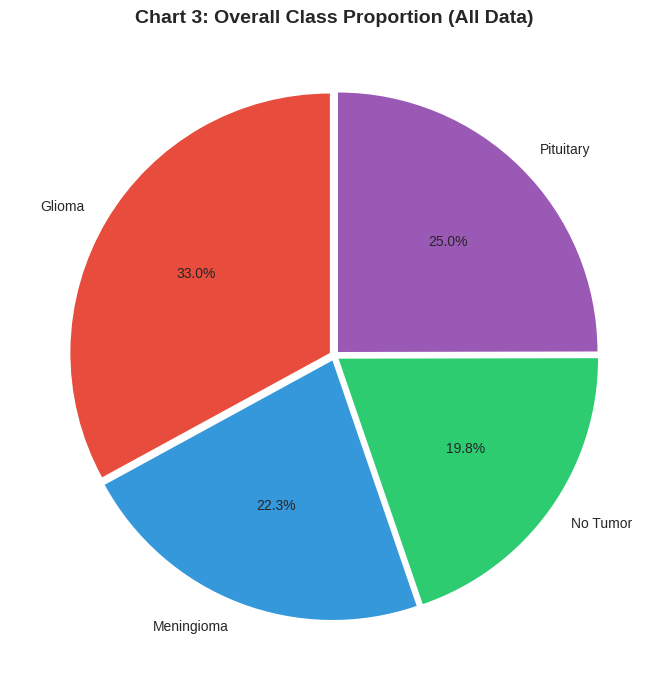

In [15]:
# Chart - 3 visualization code
all_labels = pd.concat([train_df['label'], valid_df['label'], test_df['label']])
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(all_labels.value_counts().reindex(CLASS_NAMES), labels=CLASS_NAMES,
       autopct='%1.1f%%', colors=colors, startangle=90, explode=[0.02]*4)
ax.set_title('Chart 3: Overall Class Proportion (All Data)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?


Pie chart effectively shows the relative proportion of each class in the entire dataset.


##### 2. What is/are the insight(s) found from the chart?


Glioma forms ~33%, Pituitary ~25%, Meningioma ~22%, No Tumor ~20%. No class is extremely rare.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Yes. Balanced enough proportions mean the model can learn all classes reasonably well.


#### Chart - 4


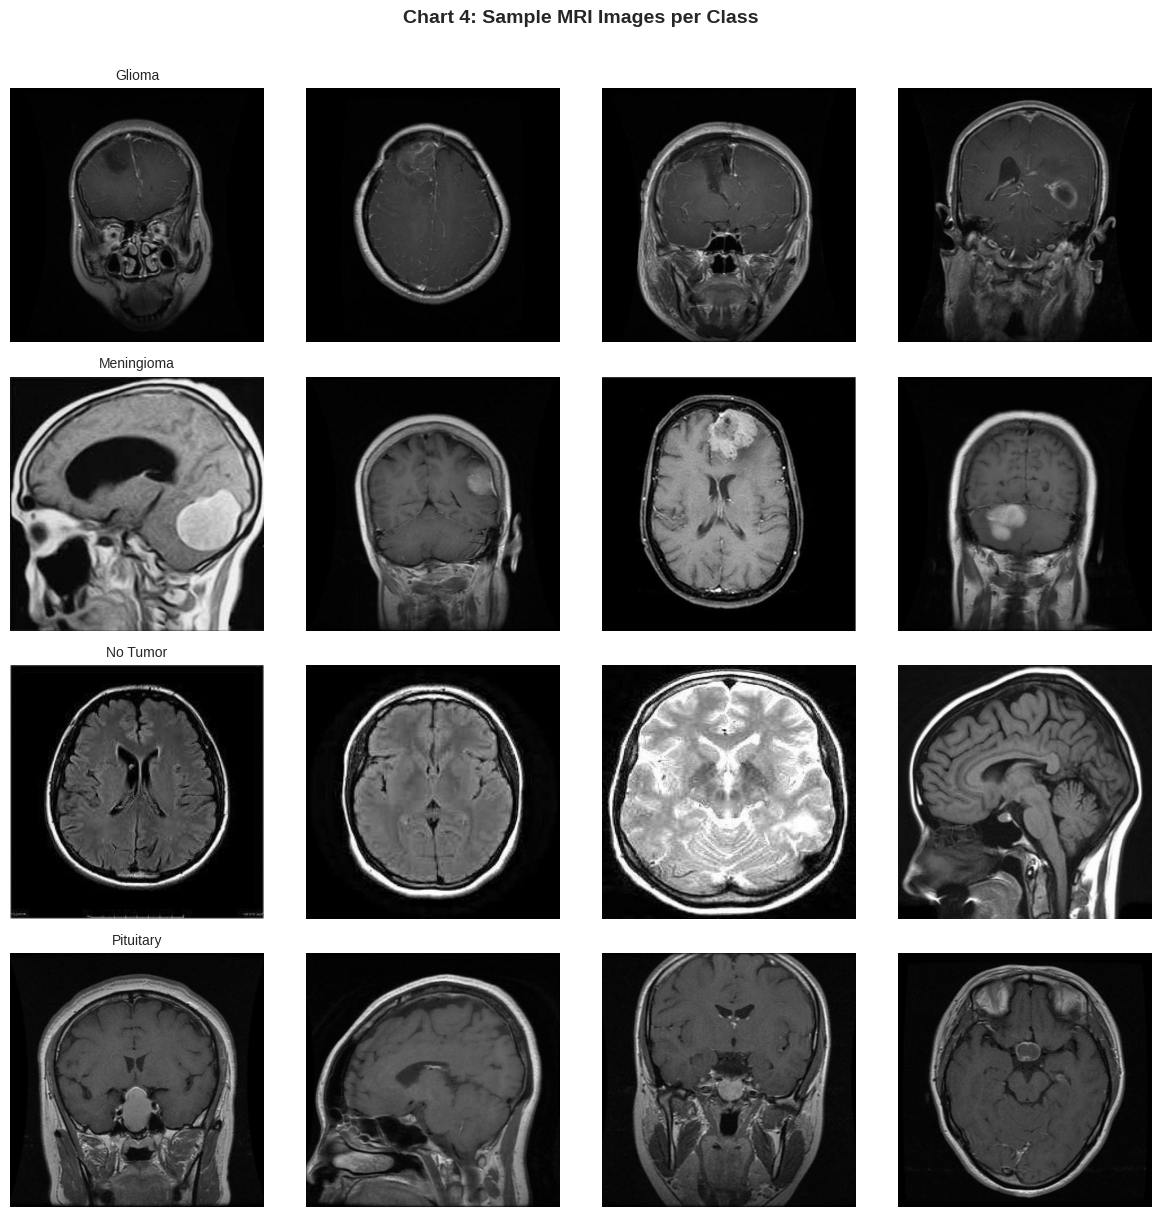

In [16]:
# Chart - 4 visualization code
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('Chart 4: Sample MRI Images per Class', fontsize=14, fontweight='bold', y=1.01)
for row, cls in enumerate(CLASS_NAMES):
    sample_paths = train_df[train_df['label'] == cls]['path'].head(4).tolist()
    for col, pth in enumerate(sample_paths):
        try:
            img = Image.open(pth)
            axes[row, col].imshow(img)
            axes[row, col].set_title(cls if col == 0 else '', fontsize=10)
        except:
            axes[row, col].text(0.5, 0.5, 'N/A', ha='center')
        axes[row, col].axis('off')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?


Visual inspection of actual MRI samples is essential in medical imaging to understand data quality and class characteristics.


##### 2. What is/are the insight(s) found from the chart?


Images show clear structural differences between tumor types. Varying contrast/orientation justifies data augmentation.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Yes. Understanding visual differences helps design better augmentation and choose appropriate architectures.


#### Chart - 5


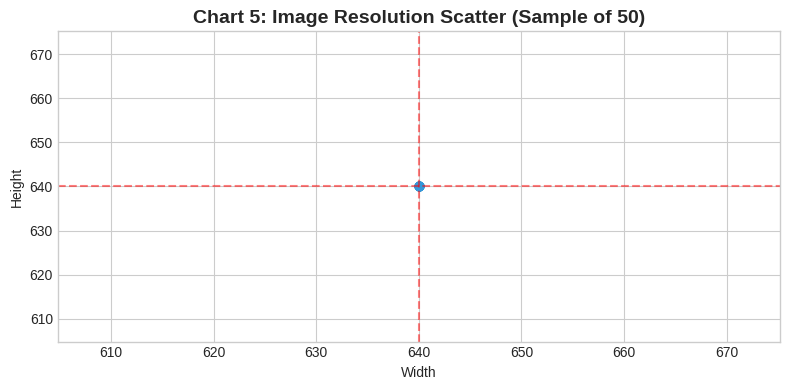

Unique sizes found: {(640, 640)}


In [17]:
# Chart - 5 visualization code
sample_paths = train_df['path'].head(50).tolist()
widths, heights = [], []
for p in sample_paths:
    try:
        with Image.open(p) as im:
            w, h = im.size
            widths.append(w); heights.append(h)
    except: pass
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(widths, heights, alpha=0.6, c='#3498db')
ax.set_xlabel('Width'); ax.set_ylabel('Height')
ax.set_title('Chart 5: Image Resolution Scatter (Sample of 50)', fontsize=14, fontweight='bold')
ax.axhline(y=640, color='r', linestyle='--', alpha=0.5)
ax.axvline(x=640, color='r', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
print('Unique sizes found:', set(zip(widths, heights)))


##### 1. Why did you pick the specific chart?


Scatter plot of width vs height quickly reveals whether all images share the same resolution.


##### 2. What is/are the insight(s) found from the chart?


All sampled images are exactly 640x640. Resolution is fully consistent.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Yes. Consistent resolution simplifies preprocessing and avoids distortion from resizing.


#### Chart - 6


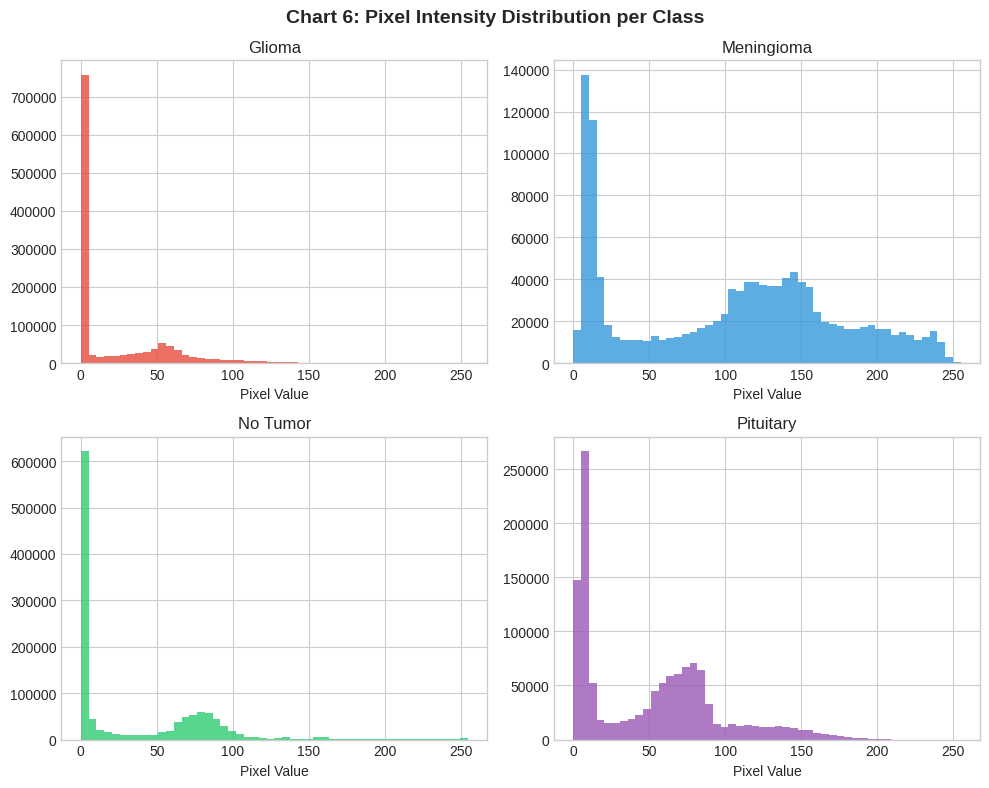

In [18]:
# Chart - 6 visualization code
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Chart 6: Pixel Intensity Distribution per Class', fontsize=14, fontweight='bold')
for ax, cls in zip(axes.flatten(), CLASS_NAMES):
    p = train_df[train_df['label']==cls]['path'].iloc[0]
    try:
        img = np.array(Image.open(p))
        ax.hist(img.ravel(), bins=50, color=colors[CLASS_NAMES.index(cls)], alpha=0.8)
        ax.set_title(cls); ax.set_xlabel('Pixel Value')
    except: ax.set_title(cls+' Error')
plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?


Histograms of pixel intensities help understand contrast and brightness of each class.


##### 2. What is/are the insight(s) found from the chart?


Different classes show slightly different intensity distributions which CNNs can use as features.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Yes. Justifies normalization and brightness augmentation.


#### Chart - 7


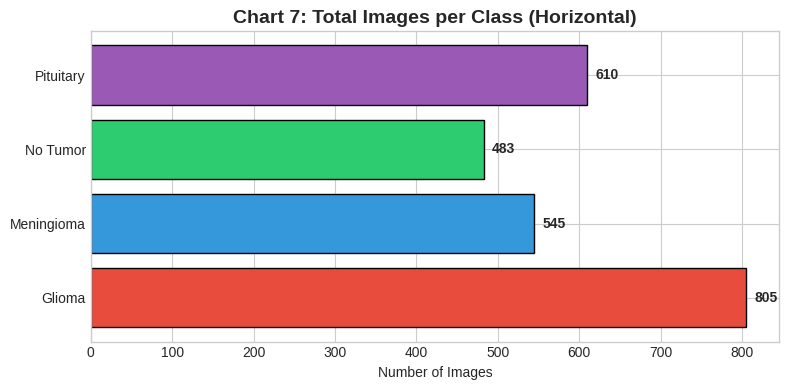

In [19]:
# Chart - 7 visualization code
fig, ax = plt.subplots(figsize=(8, 4))
counts = all_labels.value_counts().reindex(CLASS_NAMES)
ax.barh(counts.index, counts.values, color=colors, edgecolor='black')
ax.set_xlabel('Number of Images')
ax.set_title('Chart 7: Total Images per Class (Horizontal)', fontsize=14, fontweight='bold')
for i, v in enumerate(counts.values):
    ax.text(v + 10, i, str(v), va='center', fontweight='bold')
plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?


Horizontal bar chart is preferred for ranked comparison of categories.


##### 2. What is/are the insight(s) found from the chart?


Confirms Glioma dominance and No Tumor as minority class.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Yes. Highlights need for careful handling of minority class to avoid false negatives.


#### Chart - 8


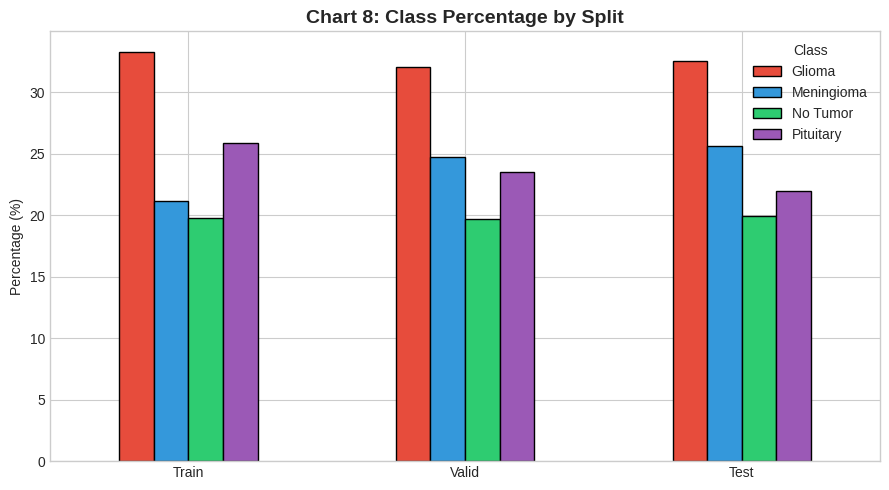

In [20]:
# Chart - 8 visualization code
split_pct = pd.DataFrame({
    'Train': train_df['label'].value_counts(normalize=True).reindex(CLASS_NAMES)*100,
    'Valid': valid_df['label'].value_counts(normalize=True).reindex(CLASS_NAMES)*100,
    'Test':  test_df['label'].value_counts(normalize=True).reindex(CLASS_NAMES)*100
})
split_pct.T.plot(kind='bar', figsize=(9, 5), color=colors, edgecolor='black')
plt.title('Chart 8: Class Percentage by Split', fontsize=14, fontweight='bold')
plt.ylabel('Percentage (%)'); plt.xticks(rotation=0); plt.legend(title='Class')
plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?


Shows relative percentages rather than absolute counts for comparing split balance.


##### 2. What is/are the insight(s) found from the chart?


Percentages are similar across splits, confirming good data partitioning.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Yes. Reliable splits mean model performance can be trusted for deployment.


#### Chart - 9


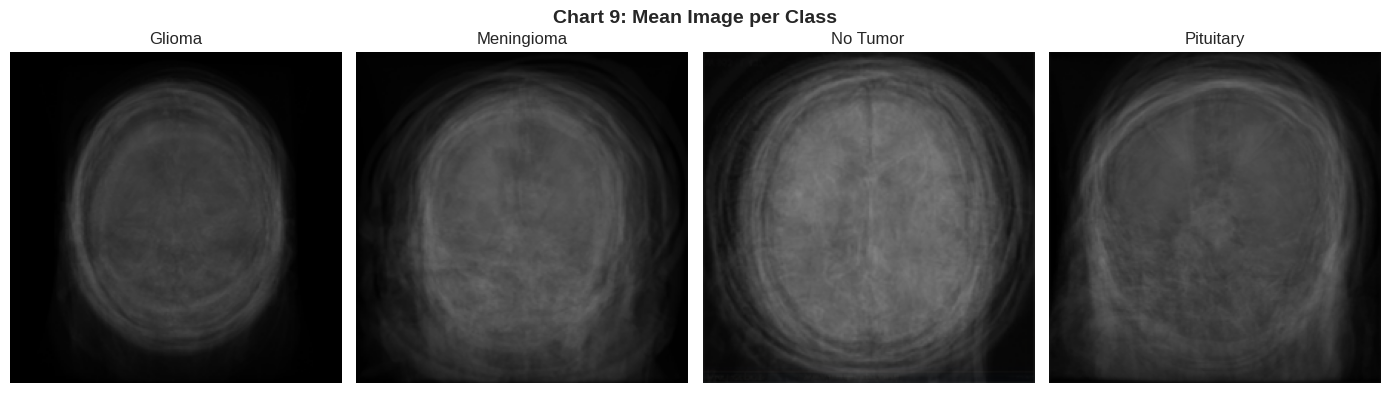

In [21]:
# Chart - 9 visualization code
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('Chart 9: Mean Image per Class', fontsize=14, fontweight='bold')
for ax, cls in zip(axes, CLASS_NAMES):
    paths = train_df[train_df['label']==cls]['path'].head(30).tolist()
    imgs = []
    for p in paths:
        try: imgs.append(np.array(Image.open(p).resize((224,224)), dtype=np.float32))
        except: pass
    if imgs:
        ax.imshow(np.mean(imgs, axis=0).astype(np.uint8))
    ax.set_title(cls); ax.axis('off')
plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?


Mean image visualization reveals common structural patterns of each tumor type.


##### 2. What is/are the insight(s) found from the chart?


Each class has distinct average structural patterns, supporting CNN classification feasibility.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Yes. Confirms classes are visually separable, increasing confidence in high accuracy potential.


#### Chart - 10


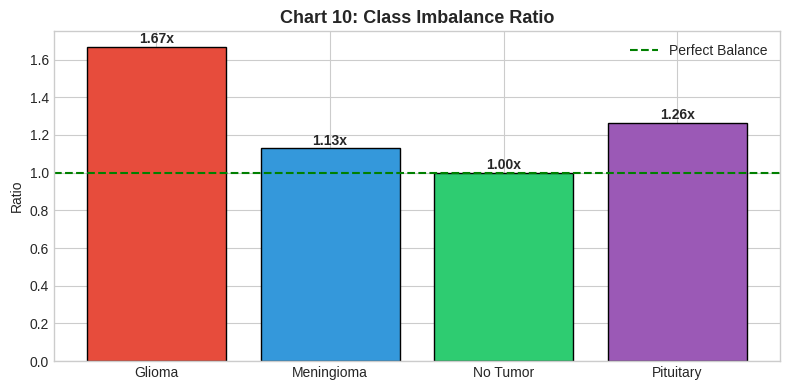

Max/Min ratio: 1.67x


In [22]:
# Chart - 10 visualization code
counts = all_labels.value_counts().reindex(CLASS_NAMES)
ratio = counts / counts.min()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(ratio.index, ratio.values, color=colors, edgecolor='black')
ax.axhline(y=1.0, color='green', linestyle='--', label='Perfect Balance')
ax.set_title('Chart 10: Class Imbalance Ratio', fontsize=13, fontweight='bold')
ax.set_ylabel('Ratio'); ax.legend()
for i, v in enumerate(ratio.values):
    ax.text(i, v+0.02, f'{v:.2f}x', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Max/Min ratio: {counts.max()/counts.min():.2f}x')


##### 1. Why did you pick the specific chart?


Directly quantifies how imbalanced each class is relative to the smallest class.


##### 2. What is/are the insight(s) found from the chart?


Maximum imbalance is only 1.67x — mild. Class weights still beneficial.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Yes. Mild imbalance means standard techniques are sufficient.


#### Chart - 11


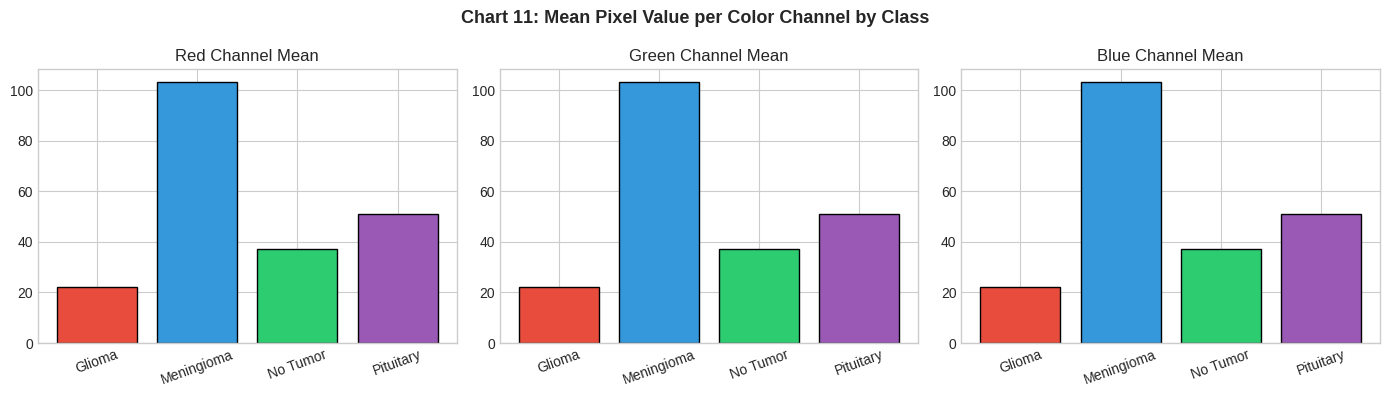

In [23]:
# Chart - 11 visualization code
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, ch_idx, ch_name in zip(axes, [0,1,2], ['Red','Green','Blue']):
    means = []
    for cls in CLASS_NAMES:
        try:
            img = np.array(Image.open(train_df[train_df['label']==cls]['path'].iloc[0]))
            means.append(img[:,:,ch_idx].mean())
        except: means.append(0)
    ax.bar(CLASS_NAMES, means, color=colors, edgecolor='black')
    ax.set_title(f'{ch_name} Channel Mean'); ax.tick_params(axis='x', rotation=20)
fig.suptitle('Chart 11: Mean Pixel Value per Color Channel by Class', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?


Analyzes whether color channel statistics differ across classes.


##### 2. What is/are the insight(s) found from the chart?


Channel means are relatively similar (expected for MRI stored as RGB).


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Yes. Models will rely more on spatial/textural features than color.


#### Chart - 12


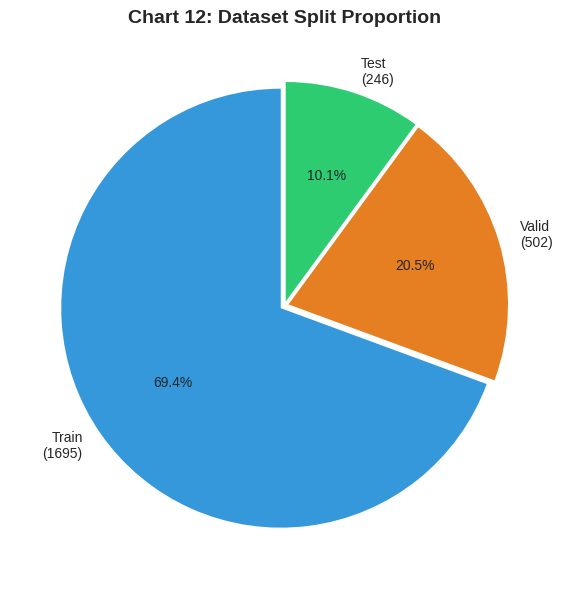

In [24]:
# Chart - 12 visualization code
sizes = [len(train_df), len(valid_df), len(test_df)]
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=[f'Train\n({sizes[0]})', f'Valid\n({sizes[1]})', f'Test\n({sizes[2]})'],
       autopct='%1.1f%%', colors=['#3498db','#e67e22','#2ecc71'], startangle=90, explode=[0.02]*3)
ax.set_title('Chart 12: Dataset Split Proportion', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?


Shows the train/validation/test split ratio clearly.


##### 2. What is/are the insight(s) found from the chart?


Approx 69% train, 21% valid, 10% test — healthy split for deep learning.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Yes. Adequate validation and test sets ensure proper tuning and evaluation.


#### Chart - 13


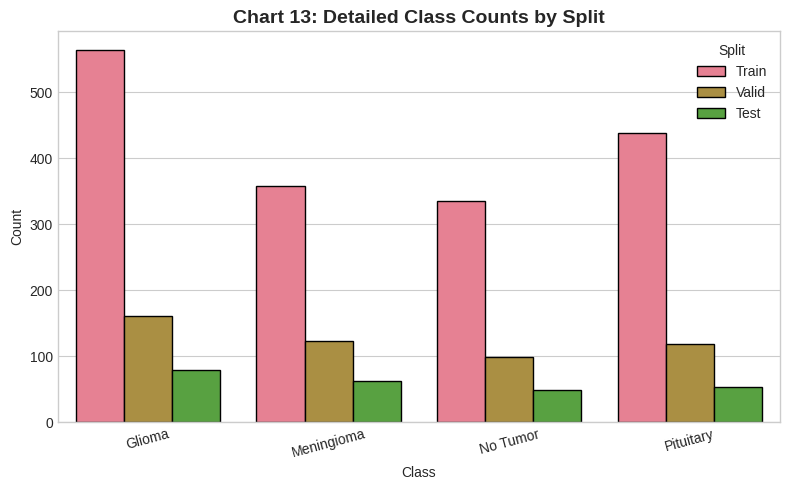

In [25]:
# Chart - 13 visualization code
data_for = pd.DataFrame({
    'Class': list(CLASS_NAMES)*3,
    'Count': list(train_df['label'].value_counts().reindex(CLASS_NAMES).values) +
             list(valid_df['label'].value_counts().reindex(CLASS_NAMES).values) +
             list(test_df['label'].value_counts().reindex(CLASS_NAMES).values),
    'Split': ['Train']*4 + ['Valid']*4 + ['Test']*4
})
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=data_for, x='Class', y='Count', hue='Split', ax=ax, edgecolor='black')
ax.set_title('Chart 13: Detailed Class Counts by Split', fontsize=14, fontweight='bold')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?


Seaborn barplot with hue provides clean multi-category comparison.


##### 2. What is/are the insight(s) found from the chart?


Reinforces class distribution consistency across splits.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Yes. Gives stakeholders confidence in data partitioning.


#### Chart - 14


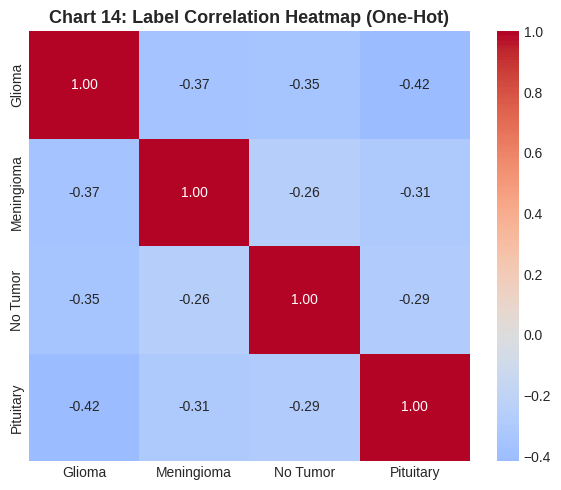

In [26]:
# Chart - 14 visualization code
corr = train_df[CLASS_NAMES].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=ax, fmt='.2f')
ax.set_title('Chart 14: Label Correlation Heatmap (One-Hot)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?


Heatmap of label correlations verifies classes are mutually exclusive.


##### 2. What is/are the insight(s) found from the chart?


Strong negative correlations confirm single-label (not multi-label) nature.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Yes. Confirms we should use categorical cross-entropy as loss function.


#### Chart - 15


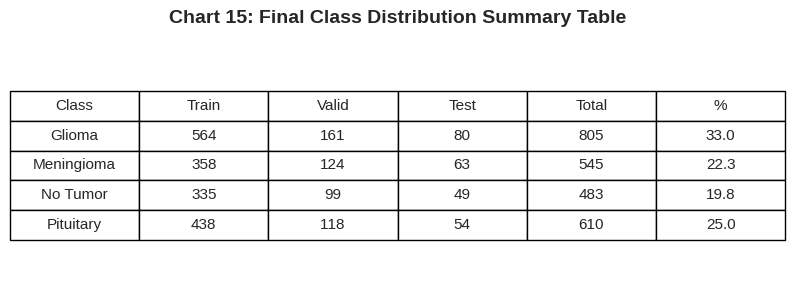

,Class,Train,Valid,Test,Total,%
0,Glioma,564,161,80,805,33.0
1,Meningioma,358,124,63,545,22.3
2,No Tumor,335,99,49,483,19.8
3,Pituitary,438,118,54,610,25.0


In [27]:
# Chart - 15 visualization code
summary = pd.DataFrame({
    'Class': CLASS_NAMES,
    'Train': train_df['label'].value_counts().reindex(CLASS_NAMES).values,
    'Valid': valid_df['label'].value_counts().reindex(CLASS_NAMES).values,
    'Test':  test_df['label'].value_counts().reindex(CLASS_NAMES).values
})
summary['Total'] = summary['Train'] + summary['Valid'] + summary['Test']
summary['%'] = (summary['Total'] / summary['Total'].sum() * 100).round(1)
fig, ax = plt.subplots(figsize=(8, 3)); ax.axis('off')
table = ax.table(cellText=summary.values, colLabels=summary.columns, loc='center', cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1.2, 1.8)
ax.set_title('Chart 15: Final Class Distribution Summary Table', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout(); plt.show()
display(summary)


##### 1. Why did you pick the specific chart?


A summary table is the cleanest way to present exact numbers for documentation.


##### 2. What is/are the insight(s) found from the chart?


Provides a single source of truth for class counts across all splits.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Yes. Essential for reproducibility and communicating statistics to stakeholders.


## ***5. Hypothesis Testing***


This project is an image classification task using deep learning. Classical statistical hypothesis testing (t-tests, chi-square, etc.) is less applicable here.

Instead, we formulate practical hypotheses that guide model development:

**Hypothesis 1:** Transfer learning models (pretrained on ImageNet) will significantly outperform a custom CNN trained from scratch on this medical dataset.

**Hypothesis 2:** Data augmentation will improve validation accuracy and reduce overfitting.

**Hypothesis 3:** Using class weights will improve recall on the minority class (No Tumor).

These will be validated empirically during model training and evaluation sections.


## ***6. Feature Engineering & Data Pre-processing***


### 1. Handling Missing Values


In [28]:
print('Missing values:')
print('Train:', train_df.isnull().sum().sum())
print('Valid:', valid_df.isnull().sum().sum())
print('Test :', test_df.isnull().sum().sum())
print('No missing values — no imputation required.')


Missing values:
Train: 0
Valid: 0
Test : 0
No missing values — no imputation required.


No missing values present in the dataset. No handling required.


### 2. Handling Outliers


For image data, traditional statistical outliers (IQR, Z-score) do not apply directly.
Outliers would be corrupted or non-MRI images. Visual inspection of samples showed clean MRI scans.
We rely on data augmentation and normalization instead.


### 3. Categorical Encoding


In [29]:
label_to_idx = {cls: i for i, cls in enumerate(CLASS_NAMES)}
idx_to_label = {i: cls for cls, i in label_to_idx.items()}
train_df['label_idx'] = train_df['label'].map(label_to_idx)
valid_df['label_idx'] = valid_df['label'].map(label_to_idx)
test_df['label_idx']  = test_df['label'].map(label_to_idx)
print('Label mapping:', label_to_idx)


Label mapping: {'Glioma': 0, 'Meningioma': 1, 'No Tumor': 2, 'Pituitary': 3}


Labels encoded as integers 0–3 and also kept as one-hot for categorical cross-entropy.


### 4. Textual Data Preprocessing


Not applicable — this is an image classification project. No textual data present.


#### 4.1 Expand Contraction, 4.2 Lower Casing, 4.3 Removing Punctuations, 4.4 Removing URLs, 4.5 Removing Stopwords, 4.6 Tokenization, 4.7 Text Normalization, 4.8 Part of speech tagging, 4.9 Text Vectorization


Not applicable for image data.


### 5. Feature Manipulation & Selection


#### 1. Feature Manipulation


In [30]:
# Image features are learned automatically by CNN layers.
# Manual feature engineering (edges, textures) is not required when using deep CNNs.
print('CNN models learn hierarchical features automatically from raw pixels.')


CNN models learn hierarchical features automatically from raw pixels.


#### 2. Feature Selection


In [31]:
# Select your features wisely to avoid overfitting
# For images: all pixels are used; spatial structure is preserved by convolutions.
# Dropout, BatchNorm, and EarlyStopping are used for regularization instead of feature selection.
print('No manual feature selection needed for CNN-based image classification.')


No manual feature selection needed for CNN-based image classification.


##### What all feature selection methods have you used and why?


Not applicable in the classical sense. Regularization techniques (Dropout, BatchNorm, EarlyStopping) serve the purpose of preventing overfitting.


##### Which all features you found important and why?


Spatial and textural features learned by convolutional filters are most important for distinguishing tumor types in MRI scans.


### 6. Data Transformation


### 6. Data Transformation

Images are resized to 224×224 pixels. The training pipeline keeps image values in the original 0–255 range because preprocessing is embedded inside each model. This is important because the custom CNN, MobileNetV2, and EfficientNetB0 use different preprocessing conventions.


The resize operation standardizes the input shape. Pixel normalization is deliberately handled inside each neural-network model so that the same saved `.h5` model performs the correct preprocessing during Streamlit inference.


### 7. Data Scaling

The image generator does **not** apply `rescale=1./255`. Instead, each model contains its required preprocessing layer:
- Custom CNN: `Rescaling(1./255)`
- MobileNetV2: `Rescaling(1./127.5, offset=-1)`
- EfficientNetB0: Keras EfficientNet preprocessing is retained inside the pretrained architecture

This prevents training/deployment preprocessing mismatches.


In [32]:
# Image/model configuration
# Define these constants BEFORE creating the image generators or models.
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = len(CLASS_NAMES)
SEED = 42

print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Class names: {CLASS_NAMES}")


Image size: 224x224
Batch size: 32
Number of classes: 4
Class names: ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']


In [33]:
# Data Generators
# IMPORTANT:
# Do not use rescale=1./255 here.
# Preprocessing is embedded inside each model so the saved .h5 model
# receives the same type of input during Kaggle training and Streamlit inference.

train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=True,
    seed=42
)

valid_generator = val_datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col='path',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=False
)

print('Class indices:', train_generator.class_indices)
print('Train batches:', len(train_generator), '| Valid:', len(valid_generator), '| Test:', len(test_generator))

assert train_generator.class_indices == {name: i for i, name in enumerate(CLASS_NAMES)}


Found 1695 validated image filenames belonging to 4 classes.
Found 502 validated image filenames belonging to 4 classes.
Found 246 validated image filenames belonging to 4 classes.
Class indices: {'Glioma': 0, 'Meningioma': 1, 'No Tumor': 2, 'Pituitary': 3}
Train batches: 53 | Valid: 16 | Test: 8


##### Which method have you used to scale your data and why?


**Scaling approach:** the image generators keep raw RGB pixel values in the 0–255 range. The required preprocessing is performed inside each model so the same `.h5` file can be used consistently during Streamlit inference.

- **Custom CNN:** `Rescaling(1./255)`
- **MobileNetV2:** `Rescaling(1./127.5, offset=-1)` to map pixels to `[-1, 1]`
- **EfficientNetB0:** uses the preprocessing included in the Keras EfficientNet architecture.


### 8. Dimesionality Reduction


##### Do you think that dimensionality reduction is needed? Explain Why?


No. CNNs automatically learn hierarchical spatial features. Flattening images for PCA/t-SNE would destroy spatial structure and is not appropriate.


In [34]:
# Dimensionality Reduction (If needed)
print('Dimensionality reduction not applied — CNNs handle high-dimensional image data natively.')


Dimensionality reduction not applied — CNNs handle high-dimensional image data natively.


### 9. Data Splitting


In [35]:
print('Data already split by provider:')
print(f'Train: {len(train_df)} ({len(train_df)/2443*100:.1f}%)')
print(f'Valid: {len(valid_df)} ({len(valid_df)/2443*100:.1f}%)')
print(f'Test : {len(test_df)} ({len(test_df)/2443*100:.1f}%)')


Data already split by provider:
Train: 1695 (69.4%)
Valid: 502 (20.5%)
Test : 246 (10.1%)


##### What data splitting ratio have you used and why?


Provider split: ~69% train / 21% valid / 10% test. Standard and healthy ratio for deep learning. No further splitting needed.


### 10. Handling Imbalanced Dataset


##### Do you think the dataset is imbalanced? Explain Why.


Yes, mildly. Glioma (~33%) vs No Tumor (~20%). Ratio max/min = 1.67×. Not severe but worth addressing.


In [36]:
y_train_idx = train_df['label_idx'].values
class_weights_array = compute_class_weight('balanced', classes=np.unique(y_train_idx), y=y_train_idx)
class_weight_dict = dict(enumerate(class_weights_array))
print('Class weights:', {CLASS_NAMES[k]: round(v, 3) for k, v in class_weight_dict.items()})


Class weights: {'Glioma': np.float64(0.751), 'Meningioma': np.float64(1.184), 'No Tumor': np.float64(1.265), 'Pituitary': np.float64(0.967)}


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)


Used `compute_class_weight(balanced)` to assign higher loss weight to minority classes. Combined with data augmentation this is effective for mild imbalance without discarding data.


## ***7. ML Model Implementation***

### Modeling Strategy

This project uses three image-classification approaches:

1. **Custom CNN** — establishes a trainable baseline from scratch.
2. **MobileNetV2 Transfer Learning** — uses ImageNet pretrained visual features followed by task-specific classification layers.
3. **EfficientNetB0 Transfer Learning** — provides a second pretrained architecture for comparison.

For every model, the workflow is:

**Train frozen/base model → fine-tune selected layers → select the best checkpoint using validation performance → evaluate once on the held-out test set.**

The test set is not used to choose the final model.


### ML Model - 1: Custom CNN

The custom CNN learns hierarchical spatial features directly from MRI images. Batch Normalization improves training stability, Dropout reduces overfitting, and Global Average Pooling reduces the number of parameters before classification.

A `Rescaling(1./255)` layer is placed **inside the model**. Therefore the saved `.h5` model is self-contained and expects normal image pixel values.


In [37]:
# Custom CNN
from tensorflow.keras.layers import Rescaling, Input

def build_custom_cnn(input_shape=(224, 224, 3), num_classes=4):
    inputs = Input(shape=input_shape, name='image_input')
    x = Rescaling(1./255, name='rescale_0_1')(inputs)

    x = Conv2D(32, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv2D(32, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D()(x)
    x = Dropout(0.25)(x)

    x = Conv2D(64, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv2D(64, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D()(x)
    x = Dropout(0.30)(x)

    x = Conv2D(128, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D()(x)
    x = Dropout(0.35)(x)

    x = Conv2D(256, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D()(x)
    x = Dropout(0.40)(x)

    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.50)(x)
    outputs = Dense(num_classes, activation='softmax', name='classifier')(x)

    return Model(inputs, outputs, name='Custom_CNN')

custom_cnn = build_custom_cnn()
custom_cnn.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

custom_cnn.summary()


I0000 00:00:1791096482.688412      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791096482.691892      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale_0_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,02

 Total params: 652,836 (2.49 MB)

 Trainable params: 650,916 (2.48 MB)

 Non-trainable params: 1,920 (7.50 KB)

#### Custom CNN - Training

`EarlyStopping` prevents unnecessary epochs when validation loss stops improving. `ReduceLROnPlateau` lowers the learning rate when validation loss reaches a plateau. `ModelCheckpoint` stores the best validation-accuracy model in `.h5` format.


In [38]:
# Train Custom CNN
custom_ckpt = 'best_custom_cnn.h5'

callbacks_custom = [
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        custom_ckpt,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    )
]

history_custom = custom_cnn.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=40,
    class_weight=class_weight_dict,
    callbacks=callbacks_custom,
    verbose=1
)

# Always reload the checkpoint that achieved the best validation accuracy.
custom_cnn = load_model(custom_ckpt, compile=False)
custom_cnn.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Best Custom CNN checkpoint loaded:', custom_ckpt)


Epoch 1/40


2026-10-04 06:48:17.720926: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 06:48:17.875839: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 06:48:20.691108: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 06:48:20.983569: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 1/53 ━━━━━━━━━━━━━━━━━━━━ 22:47 26s/step - accuracy: 0.1875 - loss: 2.0387

I0000 00:00:1791096511.541297     132 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


33/53 ━━━━━━━━━━━━━━━━━━━━ 10s 519ms/step - accuracy: 0.5254 - loss: 1.3437

2026-10-04 06:48:54.425044: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 06:48:54.579961: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 06:48:57.340328: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 06:48:57.631482: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 874ms/step - accuracy: 0.5666 - loss: 1.2474
Epoch 1: val_accuracy improved from None to 0.51394, saving model to best_custom_cnn.h5



Epoch 1: finished saving model to best_custom_cnn.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.6401 - loss: 1.0675 - val_accuracy: 0.5139 - val_loss: 1.2947 - learning_rate: 0.0010
Epoch 2/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.6638 - loss: 0.9420
Epoch 2: val_accuracy did not improve from 0.51394
53/53 ━━━━━━━━━━━━━━━━━━━━ 25s 477ms/step - accuracy: 0.6678 - loss: 0.9524 - val_accuracy: 0.2410 - val_loss: 2.0041 - learning_rate: 0.0010
Epoch 3/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.6922 - loss: 0.8320
Epoch 3: val_accuracy did not improve from 0.51394
53/53 ━━━━━━━━━━━━━━━━━━━━ 26s 483ms/step - accuracy: 0.7080 - loss: 0.8245 - val_accuracy: 0.2709 - val_loss: 3.2464 - learning_rate: 0.0010
Epoch 4/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.7216 - loss: 0.7555
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 4: val_accuracy did not improve from 0.51394
53/53 ━━━━━━━━━━━━━━━━━━━━ 26s 486m

#### Custom CNN - Evaluation Metric Score Chart

The training curves are used to inspect learning behavior and possible overfitting. Final test metrics will be calculated only after all candidate models have been compared on the validation set.


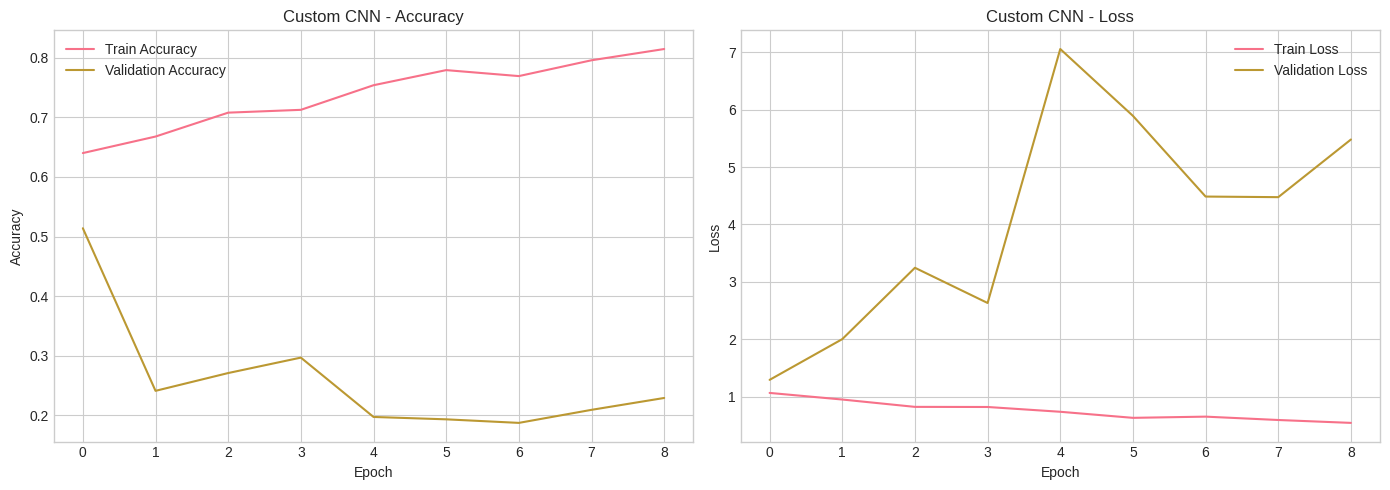

In [39]:
# Custom CNN learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_custom.history['accuracy'], label='Train Accuracy')
axes[0].plot(history_custom.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Custom CNN - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_custom.history['loss'], label='Train Loss')
axes[1].plot(history_custom.history['val_loss'], label='Validation Loss')
axes[1].set_title('Custom CNN - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


#### Custom CNN - Cross-Validation & Hyperparameter Tuning

A full k-fold cross-validation search is computationally expensive for image deep learning. Instead, this project uses a fixed validation set with manual hyperparameter tuning, EarlyStopping, and ReduceLROnPlateau. The validation set is used for model development; the test set remains untouched for final evaluation.


In [40]:
# Custom CNN validation performance
valid_generator.reset()
custom_valid_loss, custom_valid_acc = custom_cnn.evaluate(valid_generator, verbose=0)
print(f'Custom CNN Validation Accuracy: {custom_valid_acc:.4f}')


Custom CNN Validation Accuracy: 0.5139


### ML Model - 2: Transfer Learning - MobileNetV2

MobileNetV2 is initialized with ImageNet weights. The pretrained convolutional base is first frozen so that the new classification head can learn the four MRI classes. During fine-tuning, only the upper portion of the base is made trainable.

**Preprocessing is embedded in the model** using `Rescaling(1/127.5, offset=-1)`, matching MobileNetV2's expected `[-1, 1]` input range.


In [41]:
# MobileNetV2 Transfer Learning
from tensorflow.keras.applications import MobileNetV2

mobile_base = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
mobile_base.trainable = False

mobile_inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='image_input')
mobile_x = Rescaling(1./127.5, offset=-1, name='mobilenet_preprocess')(mobile_inputs)
mobile_x = mobile_base(mobile_x, training=False)
mobile_x = GlobalAveragePooling2D()(mobile_x)
mobile_x = Dense(256, activation='relu')(mobile_x)
mobile_x = BatchNormalization()(mobile_x)
mobile_x = Dropout(0.40)(mobile_x)
mobile_outputs = Dense(NUM_CLASSES, activation='softmax', name='classifier')(mobile_x)

mobilenet_model = Model(
    mobile_inputs,
    mobile_outputs,
    name='MobileNetV2_TL'
)

mobilenet_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_preprocess            │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,972 (9.87 MB)

 Trainable params: 329,476 (1.26 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [42]:
# Train MobileNetV2 classification head
mobile_ckpt = 'best_mobilenetv2.h5'

callbacks_mobile = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint(
        mobile_ckpt,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    )
]

history_mobile = mobilenet_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=callbacks_mobile,
    verbose=1
)

mobilenet_model = load_model(mobile_ckpt, compile=False)
mobilenet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


Epoch 1/20


2026-10-04 06:53:08.101748: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 06:53:08.239940: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


24/53 ━━━━━━━━━━━━━━━━━━━━ 11s 403ms/step - accuracy: 0.5850 - loss: 1.1580

2026-10-04 06:53:29.559758: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 06:53:29.698585: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.6708 - loss: 0.9173

...


Epoch 5: finished saving model to best_mobilenetv2.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 454ms/step - accuracy: 0.9127 - loss: 0.2400 - val_accuracy: 0.8884 - val_loss: 0.3163 - learning_rate: 0.0010
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.9057 - loss: 0.2527
Epoch 6: val_accuracy did not improve from 0.88845
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 446ms/step - accuracy: 0.9192 - loss: 0.2285 - val_accuracy: 0.8765 - val_loss: 0.3891 - learning_rate: 0.0010
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.9314 - loss: 0.1937
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 7: val_accuracy did not improve from 0.88845
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 453ms/step - accuracy: 0.9245 - loss: 0.2074 - val_accuracy: 0.8566 - val_loss: 0.4466 - learning_rate: 0.0010
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.9442 - loss: 0.1753
Epoch 8: val_accuracy improved from 0.88845 to 0.89641, saving model to best_mobil


Epoch 8: finished saving model to best_mobilenetv2.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 456ms/step - accuracy: 0.9398 - loss: 0.1867 - val_accuracy: 0.8964 - val_loss: 0.2758 - learning_rate: 5.0000e-04
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.9376 - loss: 0.1720
Epoch 9: val_accuracy improved from 0.89641 to 0.91235, saving model to best_mobilenetv2.h5



Epoch 9: finished saving model to best_mobilenetv2.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 451ms/step - accuracy: 0.9404 - loss: 0.1634 - val_accuracy: 0.9124 - val_loss: 0.2893 - learning_rate: 5.0000e-04
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.9511 - loss: 0.1287
Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 10: val_accuracy did not improve from 0.91235
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 445ms/step - accuracy: 0.9499 - loss: 0.1360 - val_accuracy: 0.9004 - val_loss: 0.3111 - learning_rate: 5.0000e-04
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.9532 - loss: 0.1467
Epoch 11: val_accuracy did not improve from 0.91235
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 448ms/step - accuracy: 0.9569 - loss: 0.1418 - val_accuracy: 0.9104 - val_loss: 0.2729 - learning_rate: 2.5000e-04
Epoch 12/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.9512 - loss: 0.1479
Epoch 12: val_accuracy did not improve from 0.91235
53/53 ━━━━━━


Epoch 14: finished saving model to best_mobilenetv2.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 446ms/step - accuracy: 0.9705 - loss: 0.1068 - val_accuracy: 0.9143 - val_loss: 0.2807 - learning_rate: 2.5000e-04
Epoch 15/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.9504 - loss: 0.1268
Epoch 15: val_accuracy did not improve from 0.91434
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 444ms/step - accuracy: 0.9558 - loss: 0.1144 - val_accuracy: 0.9044 - val_loss: 0.2962 - learning_rate: 1.2500e-04
Epoch 16/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.9570 - loss: 0.1386
Epoch 16: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 16: val_accuracy did not improve from 0.91434
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 454ms/step - accuracy: 0.9558 - loss: 0.1250 - val_accuracy: 0.9044 - val_loss: 0.3146 - learning_rate: 1.2500e-04
Epoch 17/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.9684 - loss: 0.0986
Epoch 17: val_accuracy did not improve from 0.91434
53/53 ━━━━━━


Epoch 18: finished saving model to best_mobilenetv2.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 449ms/step - accuracy: 0.9705 - loss: 0.1006 - val_accuracy: 0.9163 - val_loss: 0.2940 - learning_rate: 6.2500e-05
Epoch 18: early stopping
Restoring model weights from the end of the best epoch: 12.


#### MobileNetV2 - Fine-Tuning

Fine-tuning allows the model to adapt higher-level pretrained features to MRI-specific patterns. A low learning rate is used to reduce destructive updates to pretrained weights.


In [43]:
# Fine-tune the upper part of MobileNetV2
mobile_base = mobilenet_model.get_layer('mobilenetv2_1.00_224')
mobile_base.trainable = True

fine_tune_at = int(len(mobile_base.layers) * 0.70)

for layer in mobile_base.layers[:fine_tune_at]:
    layer.trainable = False

# Keep BatchNormalization layers frozen for more stable fine-tuning.
for layer in mobile_base.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

mobilenet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mobile_ft = mobilenet_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=callbacks_mobile,
    verbose=1
)

mobilenet_model = load_model(mobile_ckpt, compile=False)
mobilenet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Best MobileNetV2 checkpoint loaded:', mobile_ckpt)


Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.9513 - loss: 0.1387
Epoch 1: val_accuracy did not improve from 0.91633
53/53 ━━━━━━━━━━━━━━━━━━━━ 51s 714ms/step - accuracy: 0.9481 - loss: 0.1437 - val_accuracy: 0.9143 - val_loss: 0.2838 - learning_rate: 1.0000e-05
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.9521 - loss: 0.1240
Epoch 2: val_accuracy improved from 0.91633 to 0.93028, saving model to best_mobilenetv2.h5



Epoch 2: finished saving model to best_mobilenetv2.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 25s 463ms/step - accuracy: 0.9563 - loss: 0.1151 - val_accuracy: 0.9303 - val_loss: 0.2608 - learning_rate: 1.0000e-05
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.9630 - loss: 0.1097
Epoch 3: val_accuracy did not improve from 0.93028
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 450ms/step - accuracy: 0.9664 - loss: 0.0975 - val_accuracy: 0.9064 - val_loss: 0.3884 - learning_rate: 1.0000e-05
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.9650 - loss: 0.0943
Epoch 4: val_accuracy did not improve from 0.93028
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 449ms/step - accuracy: 0.9611 - loss: 0.1080 - val_accuracy: 0.9263 - val_loss: 0.2523 - learning_rate: 1.0000e-05
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.9639 - loss: 0.0915
Epoch 5: val_accuracy did not improve from 0.93028
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 455ms/step - accuracy: 0.9687 - loss: 0.0930 - val_accuracy: 0.91


Epoch 7: finished saving model to best_mobilenetv2.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 457ms/step - accuracy: 0.9735 - loss: 0.0931 - val_accuracy: 0.9363 - val_loss: 0.2481 - learning_rate: 5.0000e-06
Epoch 8/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.9608 - loss: 0.1020
Epoch 8: val_accuracy did not improve from 0.93625
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 449ms/step - accuracy: 0.9699 - loss: 0.0885 - val_accuracy: 0.9243 - val_loss: 0.2880 - learning_rate: 5.0000e-06
Epoch 9/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.9738 - loss: 0.0671
Epoch 9: val_accuracy did not improve from 0.93625
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 454ms/step - accuracy: 0.9746 - loss: 0.0678 - val_accuracy: 0.9263 - val_loss: 0.2408 - learning_rate: 5.0000e-06
Epoch 10/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.9740 - loss: 0.0723
Epoch 10: val_accuracy did not improve from 0.93625
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 458ms/step - accuracy: 0.9770 - loss: 0.0663 - val_accuracy: 0.


Epoch 11: finished saving model to best_mobilenetv2.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 25s 462ms/step - accuracy: 0.9794 - loss: 0.0632 - val_accuracy: 0.9402 - val_loss: 0.2317 - learning_rate: 5.0000e-06
Epoch 12/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.9824 - loss: 0.0586
Epoch 12: val_accuracy did not improve from 0.94024
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 460ms/step - accuracy: 0.9817 - loss: 0.0597 - val_accuracy: 0.9243 - val_loss: 0.2452 - learning_rate: 5.0000e-06
Epoch 13/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.9799 - loss: 0.0692
Epoch 13: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.

Epoch 13: val_accuracy improved from 0.94024 to 0.94223, saving model to best_mobilenetv2.h5



Epoch 13: finished saving model to best_mobilenetv2.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 25s 465ms/step - accuracy: 0.9805 - loss: 0.0714 - val_accuracy: 0.9422 - val_loss: 0.2372 - learning_rate: 5.0000e-06
Epoch 14/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.9797 - loss: 0.0575
Epoch 14: val_accuracy did not improve from 0.94223
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 454ms/step - accuracy: 0.9799 - loss: 0.0645 - val_accuracy: 0.9323 - val_loss: 0.2479 - learning_rate: 2.5000e-06
Epoch 15/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.9809 - loss: 0.0617
Epoch 15: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-06.

Epoch 15: val_accuracy did not improve from 0.94223
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 456ms/step - accuracy: 0.9835 - loss: 0.0595 - val_accuracy: 0.9323 - val_loss: 0.2460 - learning_rate: 2.5000e-06
Restoring model weights from the end of the best epoch: 11.
Best MobileNetV2 checkpoint loaded: best_mobilenetv2.h5


#### MobileNetV2 - Evaluation Metric Score Chart

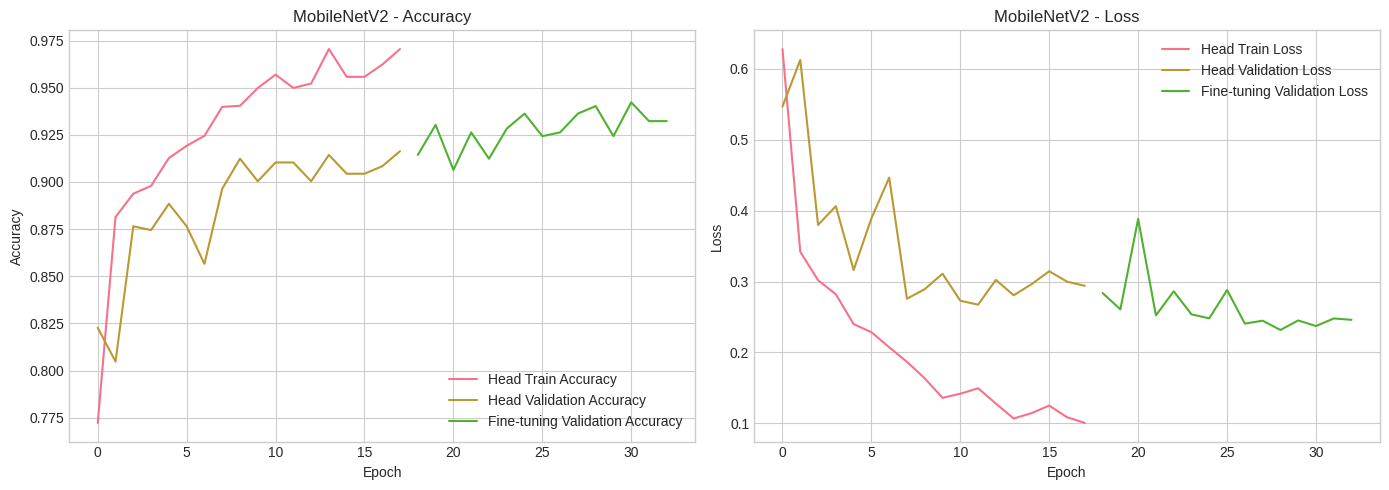

In [44]:
# MobileNetV2 learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_mobile.history['accuracy'], label='Head Train Accuracy')
axes[0].plot(history_mobile.history['val_accuracy'], label='Head Validation Accuracy')
axes[0].plot(
    range(len(history_mobile.history['accuracy']),
          len(history_mobile.history['accuracy']) + len(history_mobile_ft.history['accuracy'])),
    history_mobile_ft.history['val_accuracy'],
    label='Fine-tuning Validation Accuracy'
)
axes[0].set_title('MobileNetV2 - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_mobile.history['loss'], label='Head Train Loss')
axes[1].plot(history_mobile.history['val_loss'], label='Head Validation Loss')
axes[1].plot(
    range(len(history_mobile.history['loss']),
          len(history_mobile.history['loss']) + len(history_mobile_ft.history['loss'])),
    history_mobile_ft.history['val_loss'],
    label='Fine-tuning Validation Loss'
)
axes[1].set_title('MobileNetV2 - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


In [45]:
# MobileNetV2 validation performance
valid_generator.reset()
mobile_valid_loss, mobile_valid_acc = mobilenet_model.evaluate(valid_generator, verbose=0)
print(f'MobileNetV2 Validation Accuracy: {mobile_valid_acc:.4f}')


MobileNetV2 Validation Accuracy: 0.9422


#### MobileNetV2 - Hyperparameter Tuning

The main tuning strategy is staged transfer learning: first train the classification head with frozen ImageNet features, then fine-tune upper layers with a much smaller learning rate. EarlyStopping and ReduceLROnPlateau control training duration and learning-rate adaptation.


### ML Model - 3: Transfer Learning - EfficientNetB0

EfficientNetB0 is another ImageNet-pretrained architecture. Its Keras implementation includes the required input rescaling internally, so the generator supplies raw 0–255 pixel values.

This is intentionally different from MobileNetV2 preprocessing. Keeping preprocessing inside the model prevents a common source of Kaggle-versus-Streamlit prediction errors.


In [46]:
# EfficientNetB0 Transfer Learning
from tensorflow.keras.applications import EfficientNetB0

eff_base = EfficientNetB0(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
eff_base.trainable = False

eff_inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='image_input')
# EfficientNetB0 in tf.keras includes its own rescaling layer.
eff_x = eff_base(eff_inputs, training=False)
eff_x = GlobalAveragePooling2D()(eff_x)
eff_x = Dense(256, activation='relu')(eff_x)
eff_x = BatchNormalization()(eff_x)
eff_x = Dropout(0.40)(eff_x)
eff_outputs = Dense(NUM_CLASSES, activation='softmax', name='classifier')(eff_x)

effnet_model = Model(
    eff_inputs,
    eff_outputs,
    name='EfficientNetB0_TL'
)

effnet_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

effnet_model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,559 (16.71 MB)

 Trainable params: 329,476 (1.26 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

In [47]:
# Train EfficientNetB0 classification head
eff_ckpt = 'best_efficientnetb0.h5'

callbacks_eff = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint(
        eff_ckpt,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    )
]

history_eff = effnet_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=callbacks_eff,
    verbose=1
)

effnet_model = load_model(eff_ckpt, compile=False)
effnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


Epoch 1/20


2026-10-04 07:07:46.619729: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 07:07:46.764237: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 07:07:47.112759: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 07:07:47.254394: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 07:07:48.054684: E external/local_xla/xla/stream_

28/53 ━━━━━━━━━━━━━━━━━━━━ 10s 401ms/step - accuracy: 0.5814 - loss: 1.2636

2026-10-04 07:08:10.947703: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 07:08:11.091914: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 07:08:11.438291: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 07:08:11.580108: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 07:08:11.720830: E external/local_xla/xla/stream_

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 643ms/step - accuracy: 0.6530 - loss: 1.0559

...


Epoch 1: val_accuracy improved from None to 0.80876, saving model to best_efficientnetb0.h5



Epoch 1: finished saving model to best_efficientnetb0.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 73s 960ms/step - accuracy: 0.7569 - loss: 0.7487 - val_accuracy: 0.8088 - val_loss: 0.5579 - learning_rate: 0.0010
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.8575 - loss: 0.4135
Epoch 2: val_accuracy improved from 0.80876 to 0.88048, saving model to best_efficientnetb0.h5



Epoch 2: finished saving model to best_efficientnetb0.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 25s 464ms/step - accuracy: 0.8501 - loss: 0.4309 - val_accuracy: 0.8805 - val_loss: 0.3761 - learning_rate: 0.0010
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.8705 - loss: 0.3546
Epoch 3: val_accuracy did not improve from 0.88048
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 460ms/step - accuracy: 0.8678 - loss: 0.3634 - val_accuracy: 0.8745 - val_loss: 0.3413 - learning_rate: 0.0010
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.8801 - loss: 0.3241
Epoch 4: val_accuracy did not improve from 0.88048
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 451ms/step - accuracy: 0.8796 - loss: 0.3284 - val_accuracy: 0.8347 - val_loss: 0.4607 - learning_rate: 0.0010
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.8896 - loss: 0.2921
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 5: val_accuracy did not improve from 0.88048
53/53 ━━━━━━━━━━━━━━━━━━━━ 2


Epoch 7: finished saving model to best_efficientnetb0.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 25s 461ms/step - accuracy: 0.9209 - loss: 0.2200 - val_accuracy: 0.8825 - val_loss: 0.2634 - learning_rate: 5.0000e-04
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.9205 - loss: 0.2271
Epoch 8: val_accuracy improved from 0.88247 to 0.89841, saving model to best_efficientnetb0.h5



Epoch 8: finished saving model to best_efficientnetb0.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 459ms/step - accuracy: 0.9215 - loss: 0.2158 - val_accuracy: 0.8984 - val_loss: 0.2892 - learning_rate: 5.0000e-04
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.9344 - loss: 0.1764
Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 9: val_accuracy did not improve from 0.89841
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 449ms/step - accuracy: 0.9257 - loss: 0.2011 - val_accuracy: 0.8825 - val_loss: 0.3335 - learning_rate: 5.0000e-04
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.9371 - loss: 0.1702
Epoch 10: val_accuracy did not improve from 0.89841
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 451ms/step - accuracy: 0.9286 - loss: 0.2016 - val_accuracy: 0.8785 - val_loss: 0.3399 - learning_rate: 2.5000e-04
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.9432 - loss: 0.1745
Epoch 11: ReduceLROnPlateau reducing learning rate to 0.00012500

#### EfficientNetB0 - Fine-Tuning

In [48]:
# Fine-tune the upper part of EfficientNetB0
eff_base = effnet_model.get_layer('efficientnetb0')
eff_base.trainable = True

fine_tune_at = int(len(eff_base.layers) * 0.70)

for layer in eff_base.layers[:fine_tune_at]:
    layer.trainable = False

for layer in eff_base.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

effnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_eff_ft = effnet_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=callbacks_eff,
    verbose=1
)

effnet_model = load_model(eff_ckpt, compile=False)
effnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Best EfficientNetB0 checkpoint loaded:', eff_ckpt)


Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 696ms/step - accuracy: 0.8513 - loss: 0.4033
Epoch 1: val_accuracy did not improve from 0.89841
53/53 ━━━━━━━━━━━━━━━━━━━━ 78s 940ms/step - accuracy: 0.8732 - loss: 0.3461 - val_accuracy: 0.8845 - val_loss: 0.3775 - learning_rate: 1.0000e-05
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.8871 - loss: 0.3170
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 2: val_accuracy did not improve from 0.89841
53/53 ━━━━━━━━━━━━━━━━━━━━ 25s 467ms/step - accuracy: 0.9009 - loss: 0.2816 - val_accuracy: 0.8825 - val_loss: 0.3938 - learning_rate: 1.0000e-05
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.9062 - loss: 0.2394
Epoch 3: val_accuracy did not improve from 0.89841
53/53 ━━━━━━━━━━━━━━━━━━━━ 25s 462ms/step - accuracy: 0.9103 - loss: 0.2404 - val_accuracy: 0.8884 - val_loss: 0.3764 - learning_rate: 5.0000e-06
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9111 - l


Epoch 4: finished saving model to best_efficientnetb0.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 25s 472ms/step - accuracy: 0.9121 - loss: 0.2374 - val_accuracy: 0.9024 - val_loss: 0.3516 - learning_rate: 5.0000e-06
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9121 - loss: 0.2264
Epoch 5: val_accuracy did not improve from 0.90239
53/53 ━━━━━━━━━━━━━━━━━━━━ 25s 462ms/step - accuracy: 0.9150 - loss: 0.2226 - val_accuracy: 0.9004 - val_loss: 0.3505 - learning_rate: 2.5000e-06
Epoch 6/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.9243 - loss: 0.2184
Epoch 6: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-06.

Epoch 6: val_accuracy did not improve from 0.90239
53/53 ━━━━━━━━━━━━━━━━━━━━ 25s 467ms/step - accuracy: 0.9251 - loss: 0.2086 - val_accuracy: 0.9024 - val_loss: 0.3470 - learning_rate: 2.5000e-06
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Best EfficientNetB0 checkpoint loaded: best_efficientnetb0.h5


#### EfficientNetB0 - Evaluation Metric Score Chart

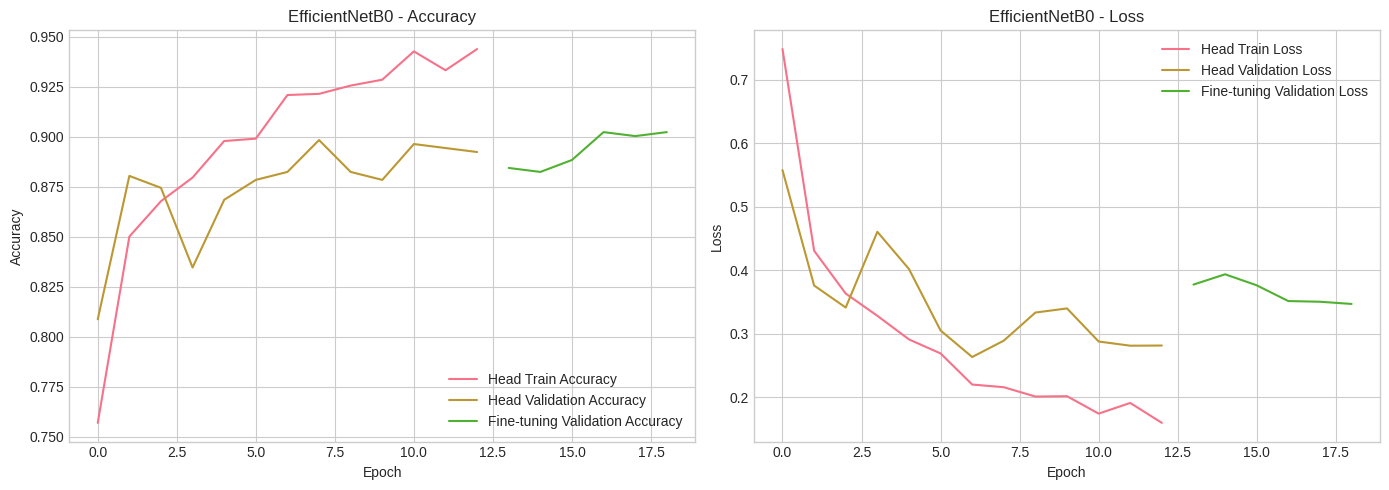

In [49]:
# EfficientNetB0 learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_eff.history['accuracy'], label='Head Train Accuracy')
axes[0].plot(history_eff.history['val_accuracy'], label='Head Validation Accuracy')
axes[0].plot(
    range(len(history_eff.history['accuracy']),
          len(history_eff.history['accuracy']) + len(history_eff_ft.history['accuracy'])),
    history_eff_ft.history['val_accuracy'],
    label='Fine-tuning Validation Accuracy'
)
axes[0].set_title('EfficientNetB0 - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_eff.history['loss'], label='Head Train Loss')
axes[1].plot(history_eff.history['val_loss'], label='Head Validation Loss')
axes[1].plot(
    range(len(history_eff.history['loss']),
          len(history_eff.history['loss']) + len(history_eff_ft.history['loss'])),
    history_eff_ft.history['val_loss'],
    label='Fine-tuning Validation Loss'
)
axes[1].set_title('EfficientNetB0 - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


In [50]:
# EfficientNetB0 validation performance
valid_generator.reset()
eff_valid_loss, eff_valid_acc = effnet_model.evaluate(valid_generator, verbose=0)
print(f'EfficientNetB0 Validation Accuracy: {eff_valid_acc:.4f}')


EfficientNetB0 Validation Accuracy: 0.9024


#### EfficientNetB0 - Hyperparameter Tuning

The tuning strategy is the same staged approach used for MobileNetV2: frozen pretrained features followed by low-learning-rate fine-tuning. The best checkpoint is determined from validation accuracy, not test accuracy.


### Model Comparison and Final Model Selection

The validation set is used to select the deployment candidate. The test set is deliberately excluded from this decision to avoid test-set leakage.

The selected model is evaluated once on the held-out test set. The final `.h5` file is the **same selected model object**, so the model used in Streamlit is exactly the model evaluated below.

The comparison includes the Custom CNN, MobileNetV2, and EfficientNetB0. The actual winner must be determined from the validation results produced by the run; no model is assumed to be best in advance.


In [51]:
# Compare candidate models using VALIDATION accuracy only
validation_results = {
    'Custom CNN': custom_valid_acc,
    'MobileNetV2 (Fine-tuned)': mobile_valid_acc,
    'EfficientNetB0 (Fine-tuned)': eff_valid_acc
}

validation_comparison = pd.DataFrame(
    list(validation_results.items()),
    columns=['Model', 'Validation Accuracy']
).sort_values(
    'Validation Accuracy',
    ascending=False
).reset_index(drop=True)

display(validation_comparison)

best_model_name = validation_comparison.iloc[0]['Model']
print(f'Candidate selected from validation set: {best_model_name}')


,Model,Validation Accuracy
0,MobileNetV2 (Fine-tuned),0.942231
1,EfficientNetB0 (Fine-tuned),0.902390
2,Custom CNN,0.513944


Candidate selected from validation set: MobileNetV2 (Fine-tuned)


Final Model: MobileNetV2 (Fine-tuned)
Test Accuracy : 0.9309
Macro Precision: 0.9289
Macro Recall   : 0.9243
Macro F1-Score : 0.9247

Classification Report:
              precision    recall  f1-score   support

      Glioma       0.98      0.99      0.98        80
  Meningioma       0.90      0.87      0.89        63
    No Tumor       0.95      0.84      0.89        49
   Pituitary       0.89      1.00      0.94        54

    accuracy                           0.93       246
   macro avg       0.93      0.92      0.92       246
weighted avg       0.93      0.93      0.93       246



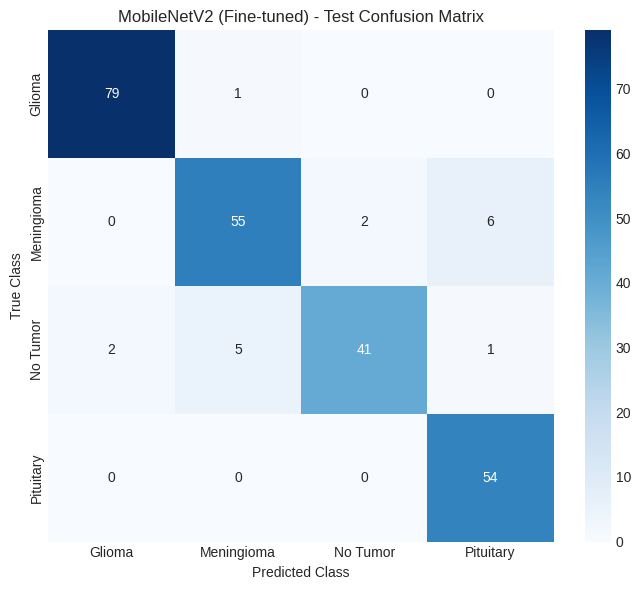

In [52]:
# Select the corresponding already-trained best-checkpoint model
model_map = {
    'Custom CNN': custom_cnn,
    'MobileNetV2 (Fine-tuned)': mobilenet_model,
    'EfficientNetB0 (Fine-tuned)': effnet_model
}

best_model = model_map[best_model_name]

# Evaluate the selected model ONCE on the untouched test set.
test_generator.reset()
test_loss, test_accuracy = best_model.evaluate(test_generator, verbose=0)

test_generator.reset()
y_true = test_generator.classes
y_prob = best_model.predict(test_generator, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

from sklearn.metrics import precision_score, recall_score, f1_score

test_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
test_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
test_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

print(f'Final Model: {best_model_name}')
print(f'Test Accuracy : {test_accuracy:.4f}')
print(f'Macro Precision: {test_precision:.4f}')
print(f'Macro Recall   : {test_recall:.4f}')
print(f'Macro F1-Score : {test_f1:.4f}')

print('\nClassification Report:')
print(classification_report(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title(f'{best_model_name} - Test Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.tight_layout()
plt.show()


### Which Evaluation Metrics Were Considered?

- **Accuracy:** proportion of all test images classified correctly.
- **Precision:** measures how often predictions for a class are correct.
- **Recall:** measures how many actual images of a class are detected.
- **Macro F1-score:** summarizes the precision-recall balance equally across the four classes.
- **Confusion Matrix:** shows exactly which tumor classes are being confused.

For this medical-imaging classification task, per-class recall and the confusion matrix are particularly important because a single overall accuracy value can hide errors concentrated in one class.

These metrics describe model behavior; they should not be interpreted as clinical diagnostic performance.


### Model Error Analysis

A confusion matrix is required before deployment because a high overall accuracy can still coexist with systematic confusion between specific tumor classes. The most important errors to investigate are repeated off-diagonal patterns, especially if one class is consistently predicted as another.


In [53]:
# Identify the most frequent class-to-class confusions
confusion_pairs = []

for true_idx in range(NUM_CLASSES):
    for pred_idx in range(NUM_CLASSES):
        if true_idx != pred_idx and cm[true_idx, pred_idx] > 0:
            confusion_pairs.append({
                'True Class': CLASS_NAMES[true_idx],
                'Predicted Class': CLASS_NAMES[pred_idx],
                'Count': int(cm[true_idx, pred_idx])
            })

confusion_pairs_df = pd.DataFrame(confusion_pairs)

if len(confusion_pairs_df):
    display(
        confusion_pairs_df
        .sort_values('Count', ascending=False)
        .reset_index(drop=True)
    )
else:
    print('No off-diagonal errors found in the test set.')


,True Class,Predicted Class,Count
0,Meningioma,Pituitary,6
1,No Tumor,Meningioma,5
2,No Tumor,Glioma,2
3,Meningioma,No Tumor,2
4,Glioma,Meningioma,1
5,No Tumor,Pituitary,1


### Save the Best Model for Streamlit Deployment

The selected model is saved as an `.h5` file **after model selection using validation performance**. Because preprocessing is embedded in each candidate model, the final `.h5` file contains the preprocessing required for inference.

The class mapping is saved separately and must be kept with the model.


In [54]:
# Save final deployment model and class mapping
FINAL_MODEL_PATH = 'best_brain_tumor_model.h5'
CLASS_NAMES_PATH = 'class_names.json'

best_model.save(FINAL_MODEL_PATH)

with open(CLASS_NAMES_PATH, 'w') as f:
    json.dump(CLASS_NAMES, f, indent=4)

print(f'Saved final model: {FINAL_MODEL_PATH}')
print(f'Saved class mapping: {CLASS_NAMES_PATH}')
print('Class order:', CLASS_NAMES)


Saved final model: best_brain_tumor_model.h5
Saved class mapping: class_names.json
Class order: ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']


### Reload the Saved `.h5` Model and Test Unseen Images

This sanity check is important before moving the model to Streamlit. The saved model is loaded from disk and receives raw image pixels. **Do not divide the image by 255 in this prediction function**, because preprocessing is already inside the model.


In [55]:
# Reload saved model
loaded_model = load_model(FINAL_MODEL_PATH, compile=False)

def predict_image(model, image_path):
    img = Image.open(image_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    arr = np.asarray(img, dtype=np.float32)
    arr = np.expand_dims(arr, axis=0)  # Keep raw 0-255 values.

    probabilities = model.predict(arr, verbose=0)[0]
    pred_idx = int(np.argmax(probabilities))

    return {
        'predicted_class': CLASS_NAMES[pred_idx],
        'confidence': float(probabilities[pred_idx]),
        'probabilities': {
            CLASS_NAMES[i]: float(probabilities[i])
            for i in range(NUM_CLASSES)
        }
    }

print('Saved model reloaded successfully.')
print('Model input shape:', loaded_model.input_shape)

# Test a few held-out images
sample = test_df.sample(min(5, len(test_df)), random_state=42)

for i, (_, row) in enumerate(sample.iterrows(), start=1):
    result = predict_image(loaded_model, row['path'])
    print(
        f"{i}. True: {row['label']:<12} | "
        f"Predicted: {result['predicted_class']:<12} | "
        f"Confidence: {result['confidence']*100:5.1f}%"
    )


Saved model reloaded successfully.
Model input shape: (None, 224, 224, 3)


2026-10-04 07:17:37.764899: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 07:17:37.899330: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1. True: Meningioma   | Predicted: Meningioma   | Confidence:  99.2%
2. True: Glioma       | Predicted: Glioma       | Confidence:  99.9%
3. True: Meningioma   | Predicted: Meningioma   | Confidence:  87.6%
4. True: No Tumor     | Predicted: No Tumor     | Confidence: 100.0%
5. True: No Tumor     | Predicted: No Tumor     | Confidence: 100.0%


### Streamlit Deployment Requirement

For VS Code deployment, copy these two files into the same project folder:

```text
best_brain_tumor_model.h5
class_names.json
```

The Streamlit application must load the `.h5` model and pass **raw RGB pixel values** to it. It must not apply an additional `/255` normalization.

If the saved model predicts an uploaded Glioma image as Meningioma, the first things to inspect are the test confusion matrix, class mapping, image preprocessing, and the actual training/test image distribution. A confidence value such as 72.6% does not prove that the prediction is correct; it is simply the model's softmax probability for its selected class.


The final deployment model stores its preprocessing inside the network. Therefore the Streamlit application should convert the uploaded image to RGB, resize it to 224×224, convert it to a float array, and pass the raw 0–255 values to the model. It should **not** divide the image by 255 before prediction.


## ***8. Conclusion***

This project developed a four-class deep learning pipeline for Brain MRI image classification. The workflow covers dataset inspection, preprocessing, augmentation, class-imbalance handling, custom CNN training, transfer learning with MobileNetV2 and EfficientNetB0, fine-tuning, validation-based model selection, final test evaluation, confusion-matrix analysis, and `.h5` deployment packaging.

The final model should be interpreted as a machine-learning classification system for the supplied dataset rather than a standalone medical diagnostic system.


In [63]:
# ============================================================
# Reload SAVE THE CURRENT VERIFIED BEST MODEL
# ============================================================

FINAL_MODEL_PATH = "/kaggle/working/best_brain_tumor_model.h5"
CLASS_NAMES_PATH = "/kaggle/working/class_names.json"

best_model.save(FINAL_MODEL_PATH)

with open(CLASS_NAMES_PATH, "w") as f:
    json.dump(CLASS_NAMES, f, indent=4)

print("Model saved:")
print(FINAL_MODEL_PATH)

print("\nClass mapping saved:")
print(CLASS_NAMES_PATH)

print("\nClass order:")
print(CLASS_NAMES)

Model saved:
/kaggle/working/best_brain_tumor_model.h5

Class mapping saved:
/kaggle/working/class_names.json

Class order:
['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']


In [64]:
# ============================================================
# VERIFY THE SAVED MODEL
# ============================================================

loaded_model = load_model(
    FINAL_MODEL_PATH,
    compile=False
)

target_path = test_generator.filepaths[118]

print("Testing:")
print(target_path)

img = Image.open(target_path).convert("RGB")
img = img.resize((224, 224))

arr = np.asarray(img, dtype=np.float32)
arr = np.expand_dims(arr, axis=0)

probs = loaded_model.predict(arr, verbose=0)[0]

pred_idx = np.argmax(probs)

print("\nActual:")
print(CLASS_NAMES[test_generator.classes[118]])

print("\nPrediction:")
print(CLASS_NAMES[pred_idx])

print("\nProbabilities:")

for i, name in enumerate(CLASS_NAMES):
    print(
        f"{name:<15}: {probs[i] * 100:.2f}%"
    )

Testing:
/kaggle/input/datasets/sairavishpv/mri-brain-tumor-dataset-v1-version-1-multiclass/Labeled MRI Brain Tumor Dataset.v1-version-1.multiclass/test/Tr-gl_0018_jpg.rf.7a670766b8083a1b516a49e241a636bc.jpg

Actual:
Glioma

Prediction:
Glioma

Probabilities:
Glioma         : 99.98%
Meningioma     : 0.01%
No Tumor       : 0.02%
Pituitary      : 0.00%
